In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and standardize names immediately to avoid previous KeyErrors
df = pd.read_csv('../Week 3/cleaned_sales_data.csv')
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# Prepare the Time-Series Data
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['year_month'] = df['order_date'].dt.to_period('M').dt.to_timestamp()

print("Presentation Environment Ready!")

Presentation Environment Ready!


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15504\3816915316.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='category', y='sales', estimator=sum, ci=None, palette='viridis', ax=ax1)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15504\3816915316.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='category', y='sales', estimator=sum, ci=None, palette='viridis', ax=ax1)


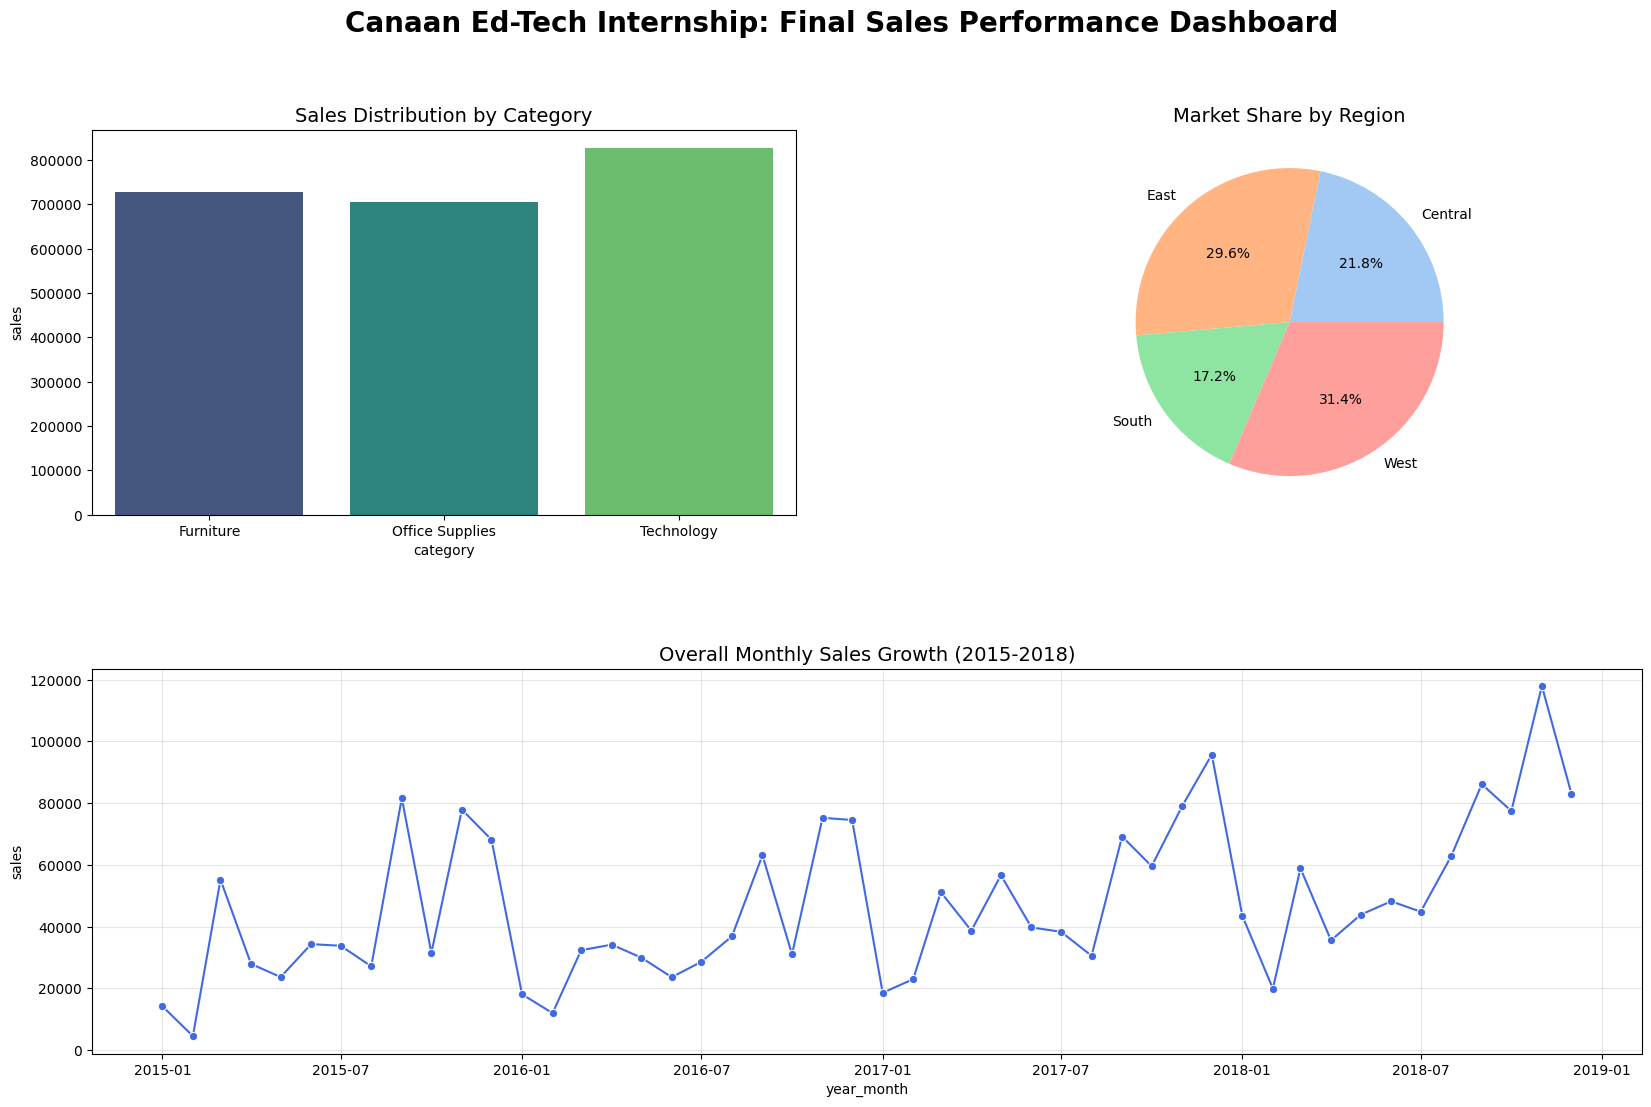

In [3]:
# Create a dashboard layout (1 row, 2 columns for the top, 1 row for the trend)
fig = plt.figure(figsize=(20, 12))
plt.subplots_adjust(hspace=0.4)

# Plot 1: Sales by Category (Bar Chart)
ax1 = plt.subplot(2, 2, 1)
sns.barplot(data=df, x='category', y='sales', estimator=sum, ci=None, palette='viridis', ax=ax1)
ax1.set_title('Sales Distribution by Category', fontsize=14)

# Plot 2: Sales by Region (Pie Chart)
ax2 = plt.subplot(2, 2, 2)
region_sales = df.groupby('region')['sales'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'), ax=ax2)
ax2.set_title('Market Share by Region', fontsize=14)
ax2.set_ylabel('')

# Plot 3: The Master Trend (Line Chart)
ax3 = plt.subplot(2, 1, 2)
monthly_sales = df.groupby('year_month')['sales'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='year_month', y='sales', color='royalblue', marker='o', ax=ax3)
ax3.set_title('Overall Monthly Sales Growth (2015-2018)', fontsize=14)
ax3.grid(True, alpha=0.3)

plt.suptitle('Canaan Ed-Tech Internship: Final Sales Performance Dashboard', fontsize=20, fontweight='bold')
plt.show()